# Unit13 Example 01 - 線性模式參數估計

本 Notebook 以**四組實驗數據**示範如何建構設計矩陣並以最小平方法估計線性模式中的未知參數，同時展示可線性化非線性模式之處理方式，最後比較兩模式的擬合品質。

## 學習目標
- 建構設計矩陣 $\mathbf{A}$ ，建立矩陣方程式 $\mathbf{B} = \mathbf{A}\boldsymbol{\theta}$
- 使用 `scipy.linalg.lstsq()` 求解最小平方問題 $\hat{\boldsymbol{\theta}} = (\mathbf{A}^T\mathbf{A})^{-1}\mathbf{A}^T\mathbf{B}$
- 對可線性化之非線性模式進行對數變換後求解
- 計算誤差平方和 $J$ 並比較不同模式之擬合品質
- 繪製實驗數據與模式預測值之比較圖

---
### 0. 環境設定

In [23]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit13_Example_01'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit13'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit13
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_01
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_01\figs


---
### 1. 載入套件

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.linalg import lstsq

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
import scipy
print(f"  scipy  版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 模式一：線性最小平方法

**模式：** $y = a + b e^{3x} + c e^{-3x}$

**實驗數據：** 4 組 $(x_i, y_i)$ ， $x = [0.5, 1, 2, 3]$ ， $y = [1, 2, 2, 1]$

**步驟：**
1. 建構設計矩陣 $\mathbf{A}$ ，各行依序為 $[1,\ e^{3x},\ e^{-3x}]$
2. 以 `scipy.linalg.lstsq(A, B)` 求解 $\hat{\boldsymbol{\theta}} = (\mathbf{A}^T\mathbf{A})^{-1}\mathbf{A}^T\mathbf{B}$

In [25]:
# ----------------------------------------
# 2.1 定義實驗數據
# ----------------------------------------
x = np.array([0.5, 1.0, 2.0, 3.0])
y = np.array([1.0, 2.0, 2.0, 1.0])

print("實驗數據:")
print(f"  x = {x}")
print(f"  y = {y}")

# ----------------------------------------
# 2.2 建構設計矩陣 A (n x 3)
#     每行依序為 [1, exp(3x), exp(-3x)]
# ----------------------------------------
A = np.column_stack([
    np.ones(len(x)),   # 常數項
    np.exp(3 * x),     # e^(3x)
    np.exp(-3 * x)     # e^(-3x)
])

B = y.copy()

print("\n設計矩陣 A:")
print(A)
print("\n觀測值向量 B:")
print(B)

實驗數據:
  x = [0.5 1.  2.  3. ]
  y = [1. 2. 2. 1.]

設計矩陣 A:
[[1.00000000e+00 4.48168907e+00 2.23130160e-01]
 [1.00000000e+00 2.00855369e+01 4.97870684e-02]
 [1.00000000e+00 4.03428793e+02 2.47875218e-03]
 [1.00000000e+00 8.10308393e+03 1.23409804e-04]]

觀測值向量 B:
[1. 2. 2. 1.]


In [26]:
# ----------------------------------------
# 2.3 使用 scipy.linalg.lstsq() 求解
# ----------------------------------------
theta, residuals, rank, sv = lstsq(A, B)

a_m1, b_m1, c_m1 = theta

print("模式一參數估計值: y = a + b*exp(3x) + c*exp(-3x)")
print(f"  a = {a_m1:.4f}")
print(f"  b = {b_m1:.4f}")
print(f"  c = {c_m1:.4f}")
print(f"\n設計矩陣秩 (rank): {rank}")

# ----------------------------------------
# 2.4 計算模式預測值與誤差平方和 J
# ----------------------------------------
y_model_1 = A @ theta         # 模式預測值
error_1   = y - y_model_1     # 誤差
J_1       = np.sum(error_1**2)  # 誤差平方和

print("\n各數據點結果:")
print(f"  {'x':>6}  {'y_exp':>8}  {'y_model':>10}  {'error':>8}")
for xi, yi, ym, ei in zip(x, y, y_model_1, error_1):
    print(f"  {xi:>6.1f}  {yi:>8.4f}  {ym:>10.4f}  {ei:>8.4f}")

print(f"\n誤差平方和 J₁ = {J_1:.4f}")

模式一參數估計值: y = a + b*exp(3x) + c*exp(-3x)
  a = 2.1539
  b = -0.0001
  c = -5.0711

設計矩陣秩 (rank): 3

各數據點結果:
       x     y_exp     y_model     error
     0.5    1.0000      1.0217   -0.0217
     1.0    2.0000      1.8985    0.1015
     2.0    2.0000      2.0837   -0.0837
     3.0    1.0000      0.9961    0.0039

誤差平方和 J₁ = 0.0178


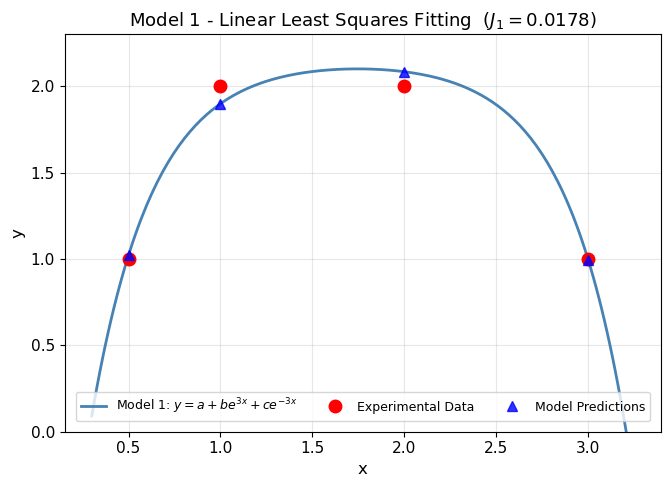

✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_01\figs\model1_fitting.png


In [27]:
# ----------------------------------------
# 2.5 繪製模式一之實驗值與預測值比較圖
# ----------------------------------------
x_fine = np.linspace(0.3, 3.25, 200)   # 限制至資料範圍附近，避免模式外插劇烈變化
A_fine = np.column_stack([
    np.ones(len(x_fine)),
    np.exp(3 * x_fine),
    np.exp(-3 * x_fine)
])
y_fine = A_fine @ theta

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_fine, y_fine, '-', color='steelblue', linewidth=2,
        label=r'Model 1: $y = a + be^{3x} + ce^{-3x}$')
ax.plot(x, y, 'ro', markersize=9, label='Experimental Data')
ax.plot(x, y_model_1, 'b^', markersize=7, alpha=0.8, label='Model Predictions')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Model 1 - Linear Least Squares Fitting  ($J_1 = {J_1:.4f}$)')
ax.set_ylim(0, 2.3)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 0.01), ncol=3, fontsize=9)
plt.tight_layout()

fig_path = FIG_DIR / 'model1_fitting.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存至: {fig_path}")

---
### 3. 同場加映：可線性化模式 $y = axe^{-bx}$

此模式表面為非線性，但對兩側除以 $x$ 後取對數：

$$
\ln\!\left(\frac{y}{x}\right) = \ln a - bx
$$

令 $\alpha = \ln a$ ，定義 $z_i = \ln y_i - \ln x_i$ ，則：

$$
z_i = \alpha - b x_i
\quad\Rightarrow\quad
\underbrace{
\begin{bmatrix} z_1 \\ z_2 \\ z_3 \\ z_4 \end{bmatrix}
}_{\mathbf{B}'}
=
\underbrace{
\begin{bmatrix}
1 & -x_1 \\ 1 & -x_2 \\ 1 & -x_3 \\ 1 & -x_4
\end{bmatrix}
}_{\mathbf{A}'}
\begin{bmatrix} \alpha \\ b \end{bmatrix}
$$

求解後由 $a = e^{\alpha}$ 還原原始參數。

In [28]:
# ----------------------------------------
# 3.1 建構線性化後的設計矩陣 A' 與觀測值 B'
# ----------------------------------------
B_prime = np.log(y) - np.log(x)           # z_i = ln(y_i) - ln(x_i)
A_prime = np.column_stack([
    np.ones(len(x)),   # 常數項 (對應 alpha)
    -x                  # -x 項 (對應 b)
])

print("線性化後的設計矩陣 A':")
print(A_prime)
print("\n線性化後的觀測值 B' (= ln(y) - ln(x)):")
print(B_prime)

# ----------------------------------------
# 3.2 求解
# ----------------------------------------
theta2, _, rank2, _ = lstsq(A_prime, B_prime)

alpha_m2, b_m2 = theta2
a_m2 = np.exp(alpha_m2)    # 還原 a = e^alpha

print(f"\n模式二參數估計值: y = a*x*exp(-b*x)")
print(f"  alpha = ln(a) = {alpha_m2:.4f}")
print(f"  b             = {b_m2:.4f}")
print(f"  a = exp(alpha)= {a_m2:.4f}")

# ----------------------------------------
# 3.3 計算模式二之預測值與誤差平方和 J₂
# ----------------------------------------
y_model_2 = a_m2 * x * np.exp(-b_m2 * x)
error_2   = y - y_model_2
J_2       = np.sum(error_2**2)

print("\n各數據點結果 (在原始 y 空間):")
print(f"  {'x':>6}  {'y_exp':>8}  {'y_model':>10}  {'error':>8}")
for xi, yi, ym, ei in zip(x, y, y_model_2, error_2):
    print(f"  {xi:>6.1f}  {yi:>8.4f}  {ym:>10.4f}  {ei:>8.4f}")

print(f"\n誤差平方和 J₂ = {J_2:.4f}")

線性化後的設計矩陣 A':
[[ 1.  -0.5]
 [ 1.  -1. ]
 [ 1.  -2. ]
 [ 1.  -3. ]]

線性化後的觀測值 B' (= ln(y) - ln(x)):
[ 0.69314718  0.69314718  0.         -1.09861229]

模式二參數估計值: y = a*x*exp(-b*x)
  alpha = ln(a) = 1.2722
  b             = 0.7386
  a = exp(alpha)= 3.5685

各數據點結果 (在原始 y 空間):
       x     y_exp     y_model     error
     0.5    1.0000      1.2333   -0.2333
     1.0    2.0000      1.7050    0.2950
     2.0    2.0000      1.6292    0.3708
     3.0    1.0000      1.1676   -0.1676

誤差平方和 J₂ = 0.3071


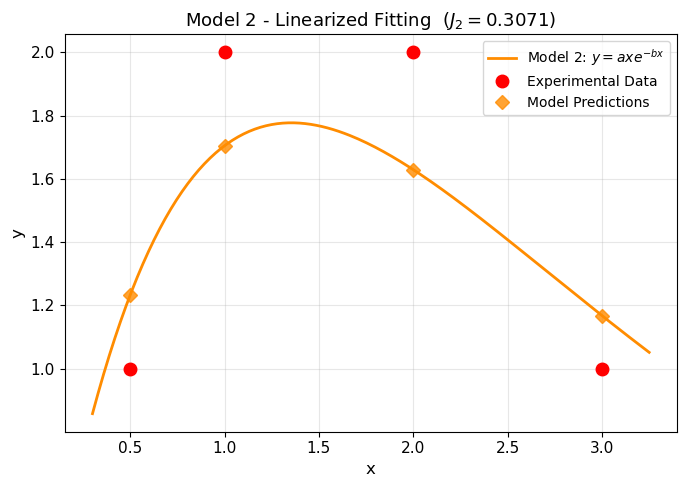

✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_01\figs\model2_fitting.png


In [29]:
# ----------------------------------------
# 3.4 繪製模式二之比較圖
# ----------------------------------------
y_fine_2 = a_m2 * x_fine * np.exp(-b_m2 * x_fine)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_fine, y_fine_2, '-', color='darkorange', linewidth=2,
        label=r'Model 2: $y = axe^{-bx}$')
ax.plot(x, y, 'ro', markersize=9, label='Experimental Data')
ax.plot(x, y_model_2, 'D', color='darkorange', markersize=7,
        alpha=0.8, label='Model Predictions')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Model 2 - Linearized Fitting  ($J_2 = {J_2:.4f}$)')
ax.legend()
plt.tight_layout()

fig_path2 = FIG_DIR / 'model2_fitting.png'
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存至: {fig_path2}")

---
### 4. 兩模式比較

以誤差平方和 $J$ 量化兩模式對此組數據的擬合品質：

$$
J = \sum_{i=1}^{n}\left(y_i - \hat{y}_i\right)^2
$$

| 模式 | 公式 | 參數數 | $J$ |
|------|------|--------|-----|
| 模式一 | $y = a + be^{3x} + ce^{-3x}$ | 3 | 見下方 |
| 模式二 | $y = axe^{-bx}$ （線性化求解） | 2 | 見下方 |

$J$ 值愈小表示擬合愈佳。

         模式比較摘要
  模式一: y = a + b*exp(3x) + c*exp(-3x)
    a = 2.1539, b = -0.0001, c = -5.0711
    J₁ = 0.0178  ← 較佳

  模式二: y = a*x*exp(-b*x)
    a = 3.5685, b = 0.7386
    J₂ = 0.3071

結論：模式一之 J 值 (0.0178) 遠小於模式二 (0.3071)
      在此組數據下，模式一對實驗數據的擬合品質明顯較佳。


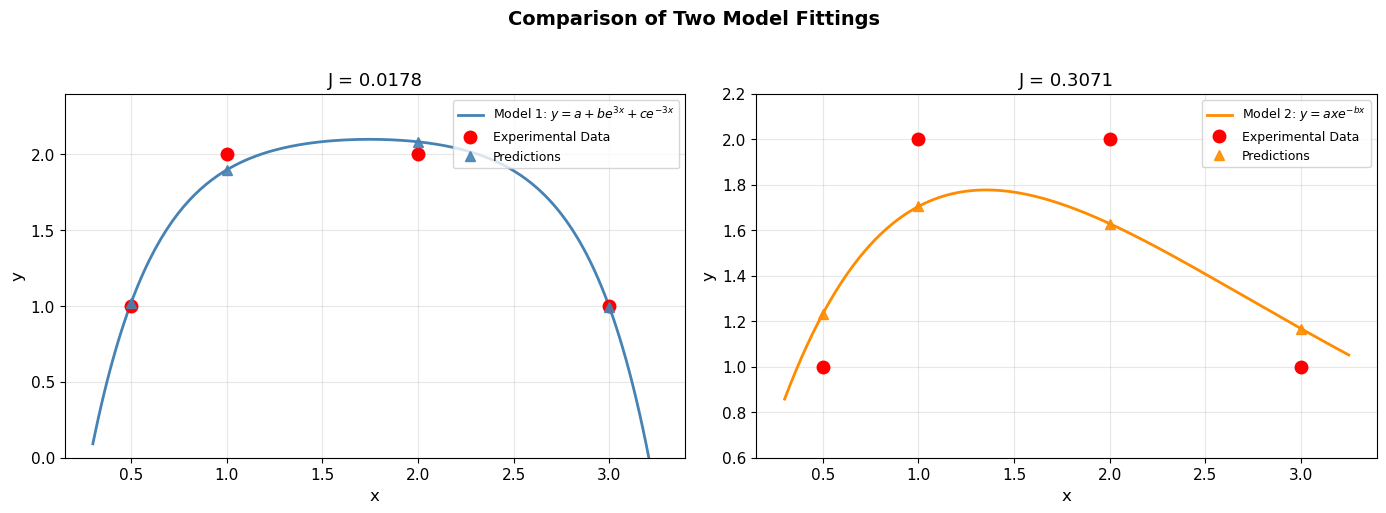

✓ 比較圖已儲存至: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Example_01\figs\model_comparison.png


In [30]:
# ----------------------------------------
# 4.1 列印模式比較摘要
# ----------------------------------------
print("=" * 55)
print("         模式比較摘要")
print("=" * 55)
print(f"  模式一: y = a + b*exp(3x) + c*exp(-3x)")
print(f"    a = {a_m1:.4f}, b = {b_m1:.4f}, c = {c_m1:.4f}")
print(f"    J₁ = {J_1:.4f}  ← 較佳")
print()
print(f"  模式二: y = a*x*exp(-b*x)")
print(f"    a = {a_m2:.4f}, b = {b_m2:.4f}")
print(f"    J₂ = {J_2:.4f}")
print("=" * 55)
print(f"\n結論：模式一之 J 值 ({J_1:.4f}) 遠小於模式二 ({J_2:.4f})")
print("      在此組數據下，模式一對實驗數據的擬合品質明顯較佳。")

# ----------------------------------------
# 4.2 繪製兩模式對比圖
# ----------------------------------------
y_fine_models = [y_fine, y_fine_2]
y_models      = [y_model_1, y_model_2]
J_vals        = [J_1, J_2]
labels        = [r'Model 1: $y = a + be^{3x} + ce^{-3x}$', r'Model 2: $y = axe^{-bx}$']
colors        = ['steelblue', 'darkorange']
ylim_ranges   = [(0.0, 2.4), (0.6, 2.2)]    # 各子圖 y 軸範圍

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_fine_m, y_model, J, label, color, ylim_r in zip(
    axes, y_fine_models, y_models, J_vals, labels, colors, ylim_ranges
):
    ax.plot(x_fine, y_fine_m, '-', color=color, linewidth=2, label=label)
    ax.plot(x, y, 'ro', markersize=9, label='Experimental Data')
    ax.plot(x, y_model, '^', color=color, markersize=7, alpha=0.9, label='Predictions')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'J = {J:.4f}')
    ax.set_ylim(ylim_r)
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle('Comparison of Two Model Fittings', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

fig_path_cmp = FIG_DIR / 'model_comparison.png'
plt.savefig(fig_path_cmp, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 比較圖已儲存至: {fig_path_cmp}")